In [1]:
import matplotlib.pyplot as plt
import numpy as np
%config InlineBackend.figure_format = 'retina'

In [2]:
s = 1.1
a = 0.3
A = np.exp(np.pi/2*s)
bump_color="#716db2"
edge_color="#1d52a1"
edge_func = lambda x, lamb: np.exp(-lamb*(1-x))
edge_func_left = lambda x, lamb: np.exp(-lamb*x)
lamb_func = lambda theta: A*np.exp(s*(theta))
lamb_func_left = lambda theta: A*np.exp(-s*theta)
theta_hat_func = lambda x: -1/s * (np.log(A) + np.log(1-x))
theta_hat_func_left = lambda x: -1/s * (np.log(A) + np.log(x))
bump_func = lambda x, theta: np.exp(-(theta-theta_hat_func(x))**2/a)
bump_func_left = lambda x, theta: np.exp(-(theta-theta_hat_func_left(x))**2/a)

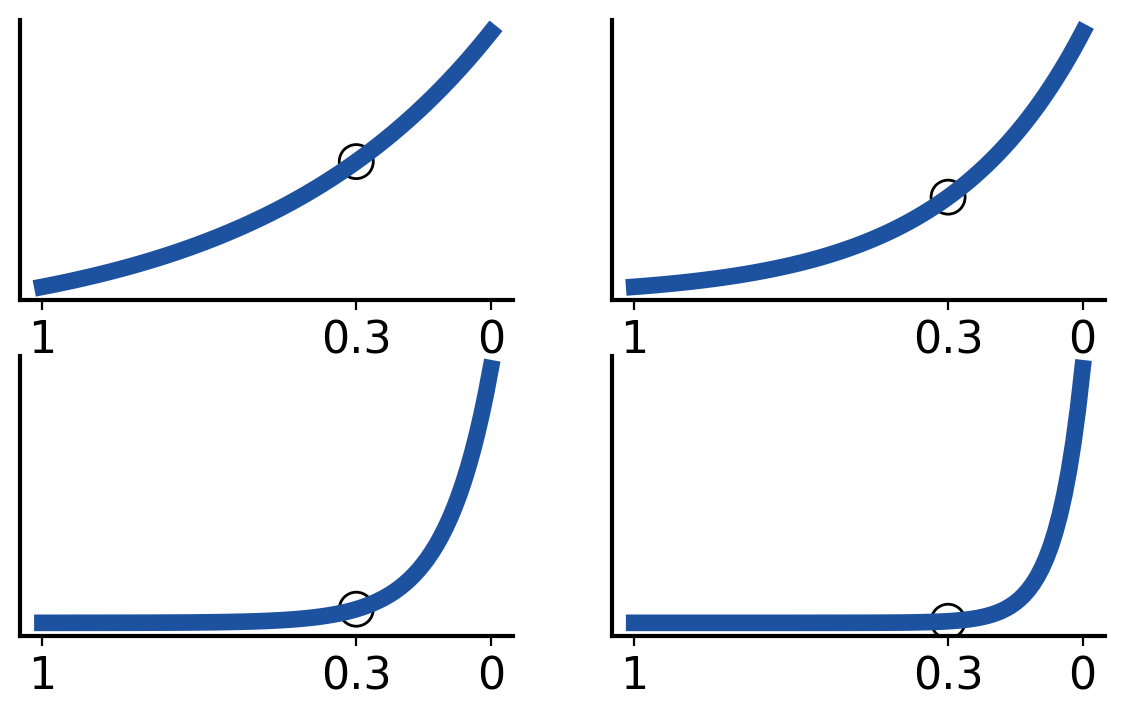

In [7]:



# 1. Data Generation
x = np.linspace(0, 1, 100)


# 2. Create Plot (2x2 layout)
theta_exp = [-1, -0.5, 0.5, 1]
fig, ax = plt.subplots(2, 2, figsize=(7, 4))
ax = ax.flatten()  # flatten to easily index with i

for i, theta in enumerate(theta_exp):
    lamb = lamb_func(theta)
    y = edge_func(x, lamb)
    
    # 3. Plotting & Styling
    ax[i].plot(x, y, linewidth=6, color=edge_color)

    # 4. mark the point where x = 0.7
    x_marker = 0.7
    y_marker = edge_func(x_marker, lamb)
    ax[i].scatter(x_marker, y_marker, facecolors='none', edgecolors='black', s=150)

    # 5. Axis Formatting
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_linewidth(1.5)
    ax[i].spines['bottom'].set_linewidth(1.5)
    ax[i].set_xticks([0, 0.7, 1], [1, 0.3, 0], fontsize=16)
    ax[i].set_yticks([])
    #ax[i].set_title(rf'$\theta = {theta}$', fontsize=12, fontweight='bold', pad=20)

    # 5. Label Formatting
    #ax[i].set_ylabel(rf'$f_{{\text{{E}}}}^{{\theta_{{{i+1}}}}}(x)$', fontsize=24, fontweight='bold', labelpad=15)



# fig, ax = plt.subplots(1, 1, figsize=(7, 4))
# for theta in np.linspace(-np.pi/2, np.pi/2, 20):
#     lamb = lamb_func(theta)
#     y = edge_func(x, lamb)
#     ax.plot(x, y, color=edge_color, linewidth=4, alpha = i/6+0.5)

#fig.savefig('../figures/figure1/edge_tunings.png', dpi=300)

/scratch/ipykernel_2010809/2636444268.py:10: RuntimeWarning: divide by zero encountered in log
  theta_hat_func = lambda x: -1/s * (np.log(A) + np.log(1-x))
/scratch/ipykernel_2010809/2636444268.py:10: RuntimeWarning: divide by zero encountered in log
  theta_hat_func = lambda x: -1/s * (np.log(A) + np.log(1-x))
/scratch/ipykernel_2010809/2636444268.py:10: RuntimeWarning: divide by zero encountered in log
  theta_hat_func = lambda x: -1/s * (np.log(A) + np.log(1-x))
/scratch/ipykernel_2010809/2636444268.py:10: RuntimeWarning: divide by zero encountered in log
  theta_hat_func = lambda x: -1/s * (np.log(A) + np.log(1-x))


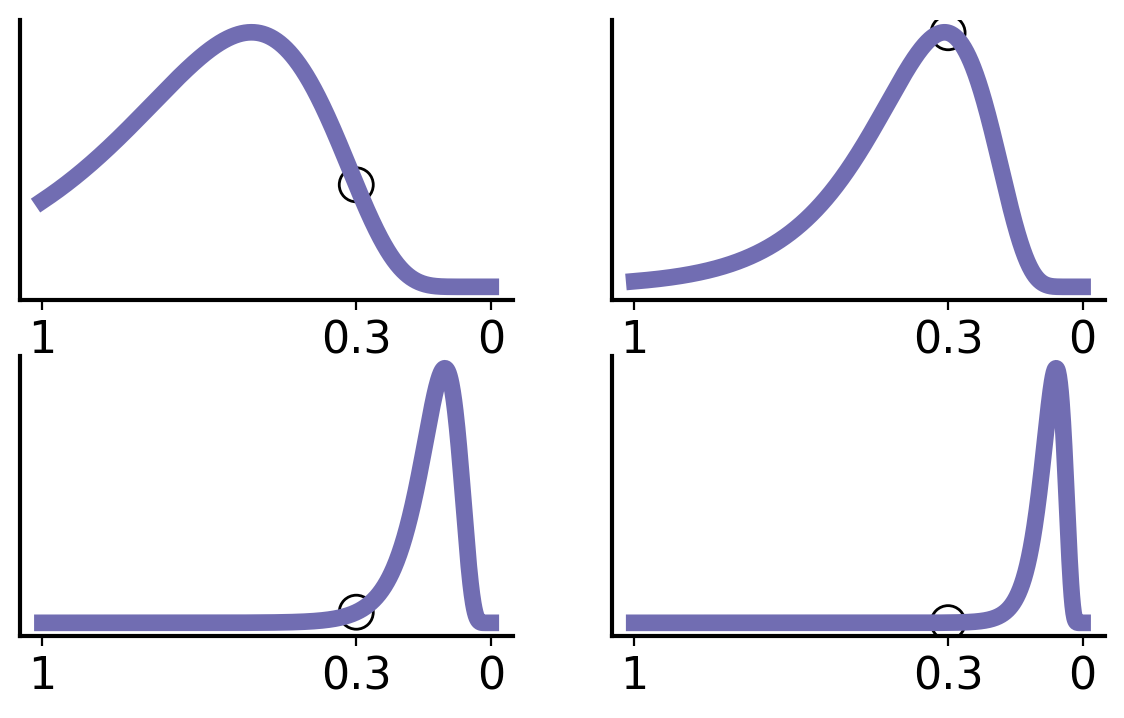

In [9]:
# 1. Data Generation
x = np.linspace(0, 1, 1000)
a = 0.3

# 2. Create Plot (2x2 layout)
theta_exp = [-1, -0.5, 0.5, 1]
fig, ax = plt.subplots(2, 2, figsize=(7, 4))
ax = ax.flatten()  # flatten to easily index with i

for i, theta in enumerate(theta_exp):
    y = bump_func(x, theta)
    
    # 3. Plotting & Styling
    ax[i].plot(x, y, linewidth=6, color=bump_color)

    # 4. mark the point where x = 0.7
    x_marker = 0.7
    y_marker = bump_func(x_marker, theta)
    ax[i].scatter(x_marker, y_marker, facecolors='none', edgecolors='black', s=150)

    # 5. Axis Formatting
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_linewidth(1.5)
    ax[i].spines['bottom'].set_linewidth(1.5)
    ax[i].set_xticks([0, 0.7, 1], [1, 0.3, 0], fontsize=16)
    ax[i].set_yticks([])

#fig.savefig('../figures/figure1/bump_tunings.png', dpi=300)

/scratch/ipykernel_626368/692612105.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


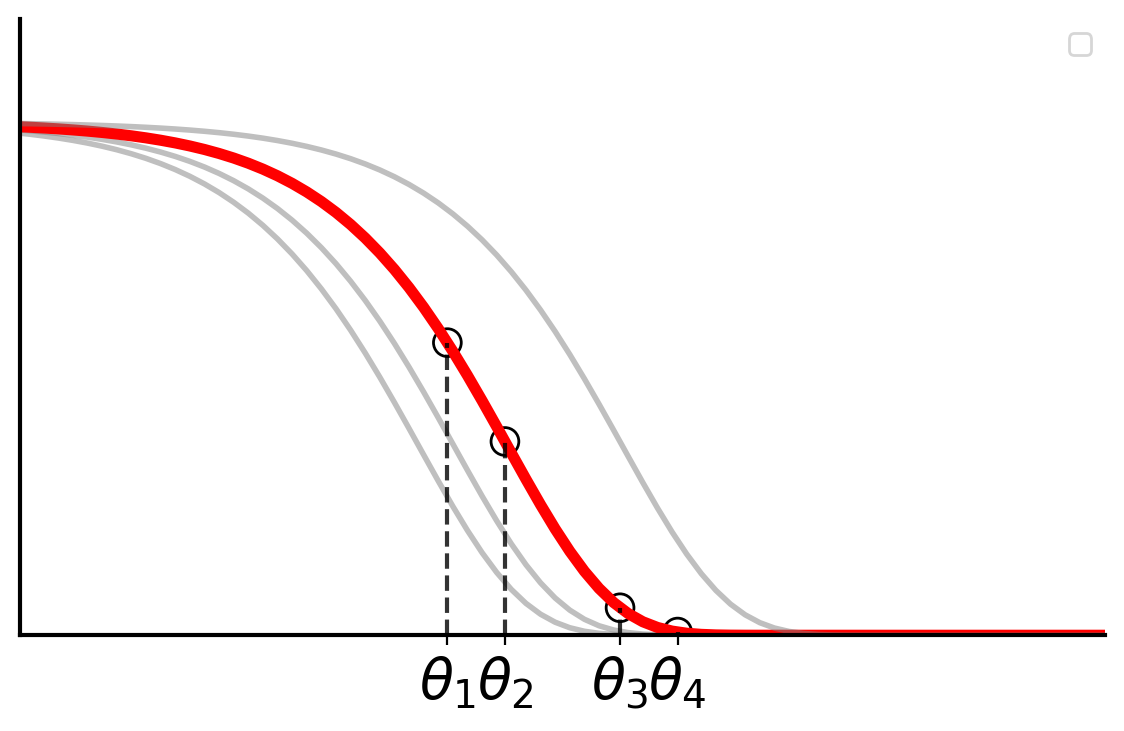

In [ ]:
theta = np.linspace(-2*np.pi, 2*np.pi, 100)
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
for i,x in enumerate([0.3, 0.5, 0.7, 0.9]):
    lamb = lamb_func(theta)
    y = edge_func(x, lamb)
    if x == 0.7:
        color = 'red'
        linewidth = 4
        alpha = 1
    else:
        color = 'grey'
        linewidth = 2
        alpha = 0.5
    ax.plot(theta, y, color=color, linewidth=linewidth, alpha = alpha)
    #theta_hat = theta_hat_func(x)
    #y_hat = edge_func(x, lamb_func(theta_hat))
    #ax.scatter(theta_hat, y_hat, color='black',  s=50)
    if x == 0.7:
        [ax.scatter(theta, edge_func(x, lamb_func(theta)),  facecolors='none', edgecolors='black',  s=100) for theta in theta_exp]
        [ax.vlines(theta, 0, edge_func(x, lamb_func(theta)), colors='black', linestyles='dashed', linewidth=1.5, alpha=0.8) for theta in theta_exp]
ax.legend()
# 4. Axis Formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_xticks(theta_exp, [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$'], fontsize=20)
#ax.set_xticks([np.min(theta), np.max(theta)])
#ax.set_xticklabels([r'$\theta_{\text{min}}$', r'$\theta_{\text{max}}$'], fontsize=16)
ax.set_yticks([])
ax.set_xlim([-1.5*np.pi, 1.5*np.pi])
ax.set_ylim([0, 1.2])
fig.savefig('../figures/figure1/edge_population_geometry.png', dpi=300)

/scratch/ipykernel_626368/1172792780.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


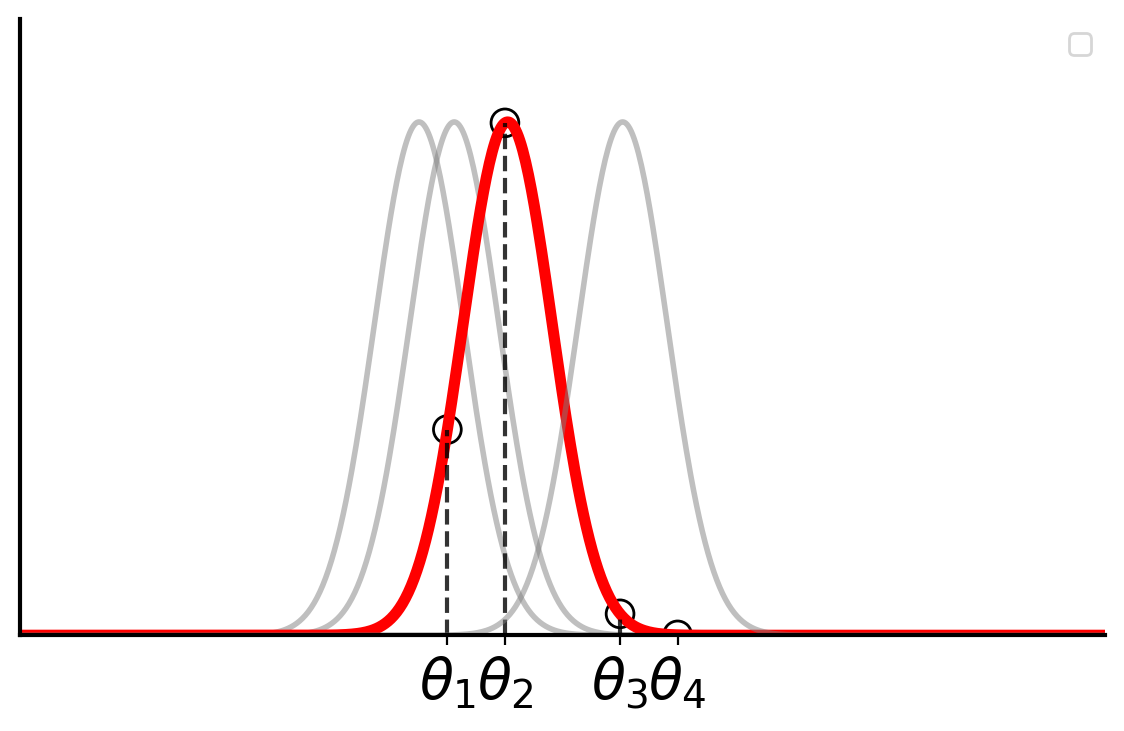

In [ ]:
theta = np.linspace(-2*np.pi, 2*np.pi, 1000)
fig, ax = plt.subplots(1, 1, figsize=(7,4))
for i, x in enumerate([0.3, 0.5, 0.7, 0.9]):

    if x == 0.7:
        color = 'red'
        linewidth = 4
        alpha = 1
    else:
        color = 'grey'
        linewidth = 2
        alpha = 0.5
    y = bump_func(x, theta)
    ax.plot(theta, y, color=color, linewidth=linewidth, alpha=alpha)
    # theta_hat = theta_hat_func(x)
    # y_hat = bump_func(x, theta_hat)
    # ax.scatter(theta_hat, y_hat, color='black', s=50)

    if x == 0.7:
        for t_exp in theta_exp:
            y_exp = bump_func(x, t_exp)
            ax.scatter(t_exp, y_exp, facecolors='none', edgecolors='black', s=100)
            # 在每个marker处往下画一条虚线到x轴
            ax.vlines(t_exp, 0, y_exp, colors='black', linestyles='dashed', linewidth=1.5, alpha=0.8)

ax.legend()
# 4. Axis Formatting
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.set_xticks([])
ax.set_xticks(theta_exp, [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$'], fontsize=20)

#ax.set_xticks([np.min(theta), np.max(theta)])
#ax.set_xticklabels([r'$\theta_{\text{min}}$', r'$\theta_{\text{max}}$'], fontsize=16)
ax.set_yticks([])
ax.set_xlim([-1.5*np.pi, 1.5*np.pi])
ax.set_ylim([0, 1.2])
fig.savefig('../figures/figure1/bump_population_geometry.png', dpi=300)

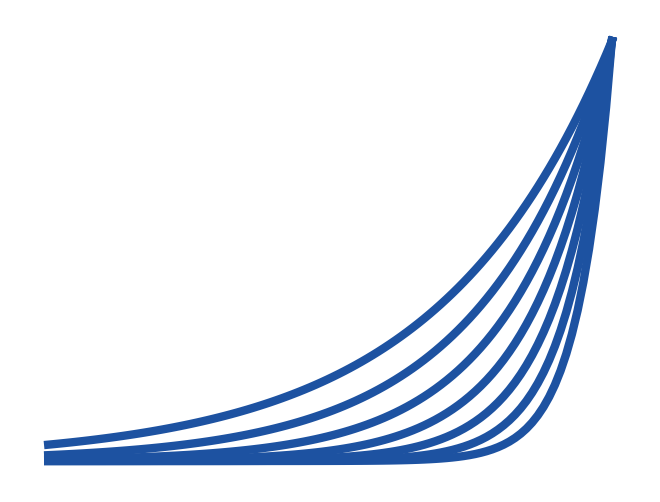

In [ ]:


# 1. Data Generation
x = np.linspace(0, 1, 100)


# 2. Create Plot (2x2 layout)
theta_exp = [-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

for i, theta in enumerate(theta_exp):
    lamb = lamb_func(theta)
    y = edge_func(x, lamb)
    
    # 3. Plotting & Styling
    ax.plot(x, y, linewidth=3, color=edge_color)

   

    # 5. Axis Formatting
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)
    ax.set_xticks([])
    ax.set_yticks([])
    

fig.savefig('../figures/figure1/ramping_scheme.png', dpi=300)

/scratch/ipykernel_626368/2636444268.py:10: RuntimeWarning: divide by zero encountered in log
  theta_hat_func = lambda x: -1/s * (np.log(A) + np.log(1-x))


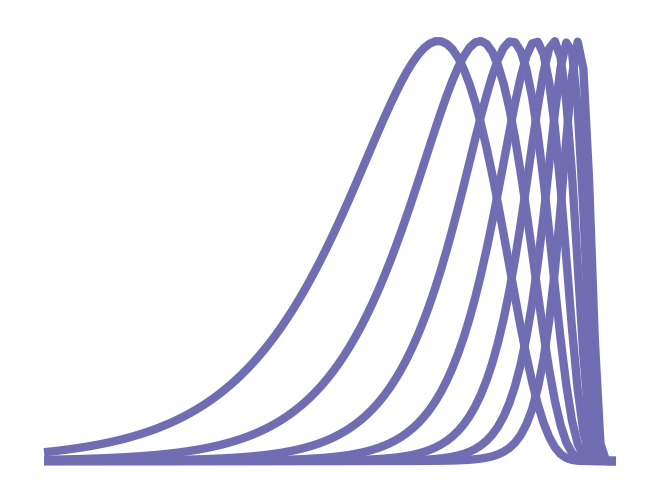

In [ ]:


# 1. Data Generation
x = np.linspace(0, 1, 100)


# 2. Create Plot (2x2 layout)
theta_exp = [ -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
fig, ax = plt.subplots(1, 1, figsize=(4, 3))

for i, theta in enumerate(theta_exp):
    y = bump_func(x, theta)
    
    # 3. Plotting & Styling
    ax.plot(x, y, linewidth=3, color=bump_color)

   

    # 5. Axis Formatting
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(False)
    ax.spines['bottom'].set_linewidth(False)
    ax.set_xticks([])
    ax.set_yticks([])
    #ax[i].set_title(rf'$\theta = {theta}$', fontsize=12, fontweight='bold', pad=20)


fig.savefig('../figures/figure1/sequential_scheme.png', dpi=300)